Customer Churn Prediction and Analysis

## Project Overview

This project analyzes customer data to identify patterns associated with
bank customer churn and builds machine learning models to predict whether
a customer is likely to leave.

The project covers data cleaning, exploratory data analysis, preprocessing,
classification, model evaluation, and feature importance.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 2. Data Inspection & Cleaning

In [2]:
df= pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 14)

In [4]:
#Basic information 
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

### Removing Irrelevant Columns

`RowNumber`, `CustomerId`, and `Surname` were removed because they do not
provide meaningful predictive information for customer churn.

In [7]:
#Remove unnecessary columns 
df= df.drop(['RowNumber', 'CustomerId', 'Surname'], axis= 1,errors='ignore')


In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns 

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

The dataset was checked for missing values, duplicate records, and
inconsistent data types before performing further analysis.

## Exploratory Data Analysis

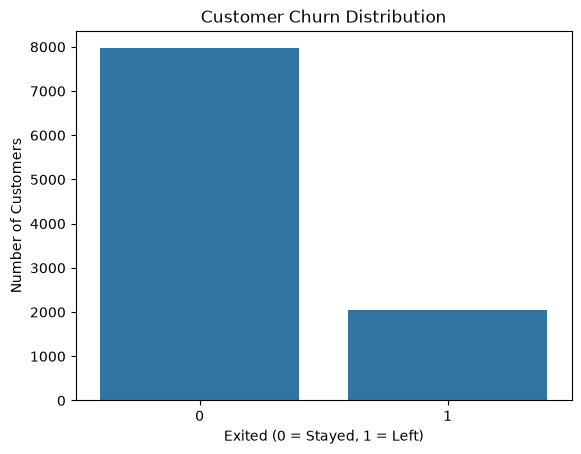

In [11]:
sns.countplot(x="Exited", data= df)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()

### Churn Rate by Geography

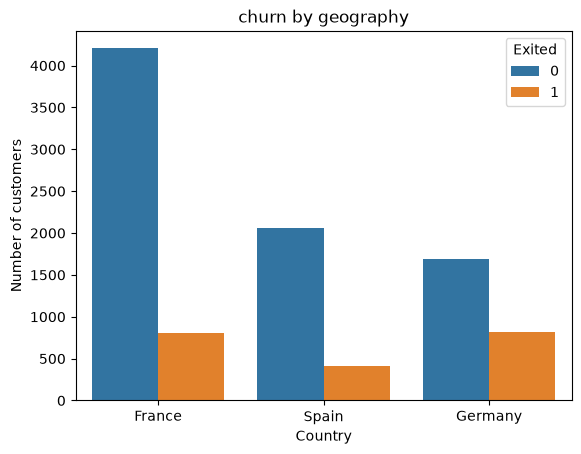

In [12]:
sns.countplot(x="Geography", hue="Exited", data= df)
plt.title("churn by geography")
plt.xlabel("Country")
plt.ylabel("Number of customers")
plt.show()

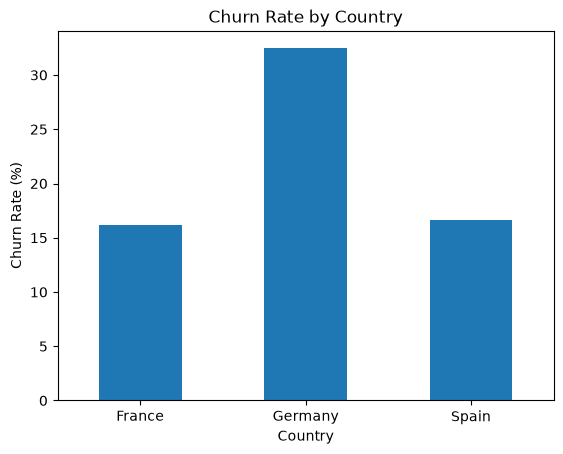

In [13]:
#what percentage of customers churned in each country 
churn_by_country = df.groupby("Geography")["Exited"].mean() * 100

churn_by_country.plot(kind="bar")

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Germany has the highest observed churn rate among the three countries
in this dataset.

### Churn Rate and Age

In [14]:
df.groupby("Exited")["Age"].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

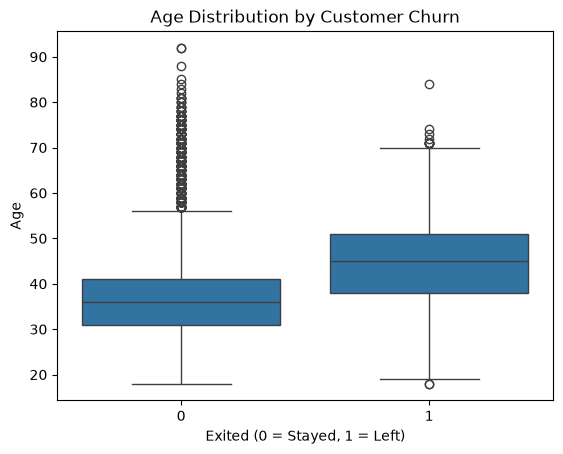

In [15]:
sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Age")

plt.show()

Customers who churned were generally older than customers who stayed
in this dataset.

### Churn and Membership Activity

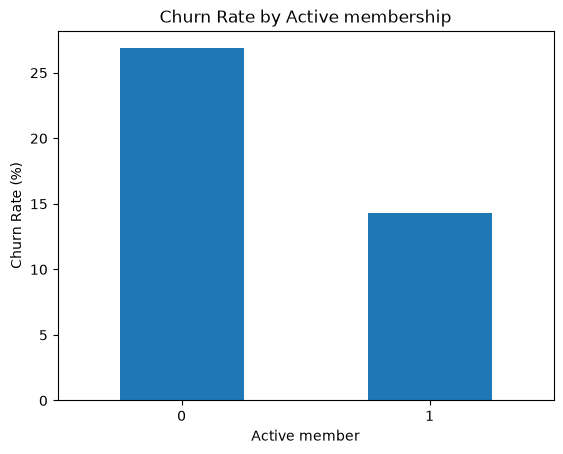

In [16]:
#does being an active member make you less likely to churn?
member= df.groupby("IsActiveMember")["Exited"].mean()*100
member.plot(kind= "bar")
plt.title("Churn Rate by Active membership")
plt.xlabel("Active member")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()


Active members showed a lower observed churn rate than inactive members.
This represents an association in the dataset and does not establish causation.

## Data Preprocessing for Machine Learning

The target variable `Exited` was separated from the input features.
Categorical variables were converted into numerical representations
using one-hot encoding.

In [17]:
X= df.drop("Exited", axis=1)
y=df["Exited"]

In [18]:
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [19]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [20]:

X = df.drop("Exited", axis=1)


X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train-Test Split

The data was divided into training and testing sets. The training set
was used to train the models, while the test set was reserved for
evaluating performance on unseen data.


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.35649971, -0.6557859 ,  0.34567966, -1.21847056,  0.80843615,
         0.64920267,  0.97481699,  1.36766974, -0.57946723, -0.57638802,
         0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 ,  0.69683765,  0.80843615,
         0.64920267,  0.97481699,  1.6612541 ,  1.72572313, -0.57638802,
         0.91324755],
       [-0.96147213, -1.41636539, -0.69539349,  0.61862909, -0.91668767,
         0.64920267, -1.02583358, -0.25280688, -0.57946723,  1.73494238,
         0.91324755],
       [-0.94071667, -1.13114808,  1.38675281,  0.95321202, -0.91668767,
         0.64920267, -1.02583358,  0.91539272, -0.57946723, -0.57638802,
        -1.09499335],
       [-1.39733684,  1.62595257,  1.38675281,  1.05744869, -0.91668767,
        -1.54035103, -1.02583358, -1.05960019, -0.57946723, -0.57638802,
         0.91324755]])

### Feature Scaling

StandardScaler was applied to the training features so that numerical
variables with different ranges could be used on a comparable scale.

The scaler was fitted only on the training data and then applied to the
test data to avoid data leakage.

## Logistic Regression

Logistic Regression was used as a baseline classification model for
predicting whether a customer would churn.

In [29]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
pred= model.predict(X_test_scaled)


In [30]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.811


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1543   64]
 [ 314   79]]


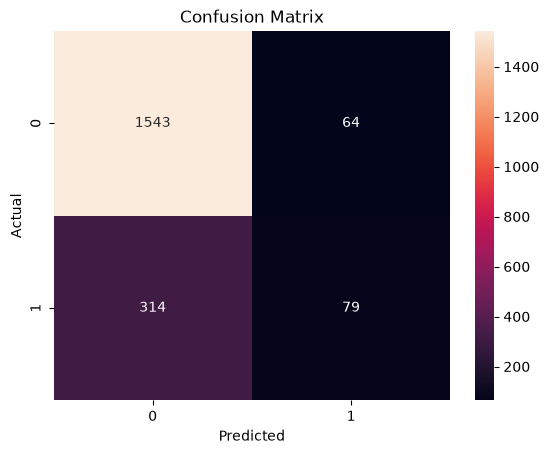

In [33]:
sns.heatmap(cm, annot=True, fmt= "d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression Evaluation

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))



#we can conclude that are model is having difficulty predictiing customers who actually churned 

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### Classification Metrics

- **Precision:** Among customers predicted as churners, the proportion
  who actually churned.
- **Recall:** Among customers who actually churned, the proportion
  correctly identified by the model.
- **F1-score:** A combined measure of precision and recall.
- **Support:** Number of actual observations in each class.

## Random Forest

A Random Forest classifier was trained to capture potentially non-linear
relationships between customer characteristics and churn.

In [35]:
from sklearn.ensemble import RandomForestClassifier
rfmodel= RandomForestClassifier(n_estimators=100, random_state=42)
rfmodel.fit(X_train, y_train)
rfpred= rfmodel.predict(X_test)

### Random Forest Evaluation

In [37]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rfpred)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, rfpred))

Random Forest Accuracy: 0.8665

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [38]:
from sklearn.metrics import confusion_matrix
cmrf= confusion_matrix(y_test, rfpred)
print(cmrf)

[[1548   59]
 [ 208  185]]


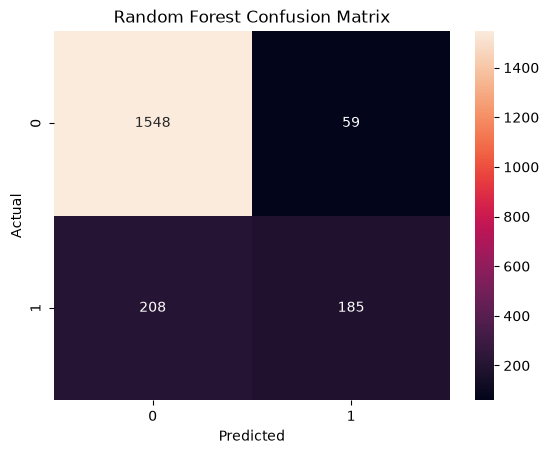

In [39]:
sns.heatmap(cmrf, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest achieved higher performance than Logistic Regression on
the test set, particularly for identifying customers in the churn class.

In [41]:
feature_importance= pd.Series(rfmodel.feature_importances_, index= X_train.columns).sort_values(ascending= False)
print(feature_importance)

Age                  0.236922
EstimatedSalary      0.147558
CreditScore          0.143338
Balance              0.141612
NumOfProducts        0.131486
Tenure               0.082080
IsActiveMember       0.040725
Geography_Germany    0.026190
HasCrCard            0.018454
Gender_Male          0.018421
Geography_Spain      0.013214
dtype: float64


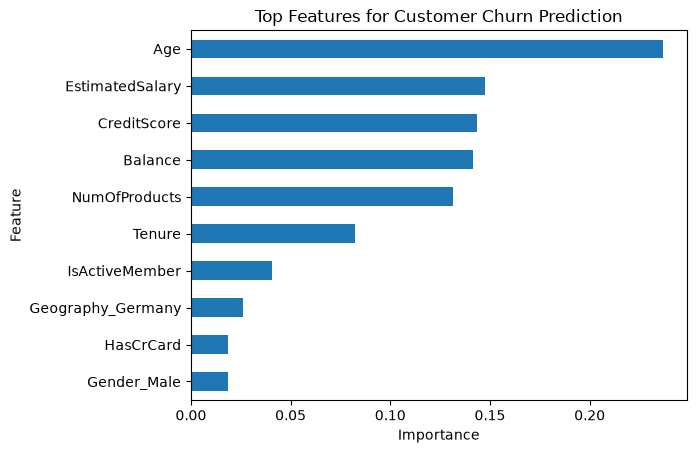

In [42]:
feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top Features for Customer Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [43]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Churn Precision": [0.55, 0.76],
    "Churn Recall": [0.20, 0.47],
    "Churn F1": [0.29, 0.58]
})

comparison

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.8110,0.55,0.20,0.29
1,Random Forest,0.8665,0.76,0.47,0.58


## Key Findings & Conclusion

### Key Findings

- The dataset contains 10,000 customer records.
- Customer churn is less frequent than customer retention.
- Germany had the highest observed churn rate among the three countries.
- Churned customers were generally older than customers who stayed.
- Active members showed a lower observed churn rate than inactive members.
- Random Forest performed better than Logistic Regression on the test set.
- Age had the highest feature importance in the Random Forest model.

### Conclusion

This project demonstrates an end-to-end customer churn analysis workflow,
including data cleaning, exploratory analysis, preprocessing, classification,
model evaluation, and model interpretation.